## CP decomposition: a quadratic-in-modes algorithm for the multimode generalized nonlinear Schrodinger equation

The purpose of this notebook is to illustrate with examples the CP decomposition, a tensor decomposition that admits a high-accuracy and low-rank representation of the four-wave-mixing tensor. The low-rank enables simulating highly multimode dynamics at lower cost than with the standard dense representation.

In [1]:
using Pkg

ROOT = abspath(joinpath(@__DIR__, ".."))
Pkg.activate(ROOT)

using PulsePropagation
using FFTW
using LinearAlgebra
using PyPlot
using DelimitedFiles

  Activating project at `~/FastDifferentiableMMNLO`


In [2]:
c_light = 2.99792458e-4; # m/ps -- see manual for unit system info
Nt = 2^13;
time_window = 100; # ps
λ0 = 1550e-9; # m
ω0 = 2*π*c_light/λ0;

time_grid = TimeGrid(Nt,time_window);
t = time_axis(time_grid);
Ω = frequency_axis(time_grid); # constructs relative frequency
ω = ω0 .+ Ω; # absolute frequency;
λ = wavelength_axis(time_grid,ω0); # wavelength

dofs = degrees_of_freedom(:time, :space)
domain = MMGNLSEDomain(dofs, time_grid);

In the cell below, we probe the runtime scaling for a single-step of the MMGNLSE as a function of the number of modes. This provides a good proxy for the total runtime using a fixed-step method. We use a fixed random 10-mode launch.

In [8]:
core_radius = 52.5e-6;
NA = 0.1;
material = Silica() # The default Silica picks an anisotropic Raman model. See other notebooks such as soliton_jitter for other Raman models;
step_fiber = StepIndex(λ0, core_radius, NA);
Δz = 1e-5;

mode_numbers = [15:5:40;];
run_time_s = zeros(length(mode_numbers));

for ii = 1:length(mode_numbers)
    
    num_modes = mode_numbers[ii];
    properties = compute_fiber_properties(step_fiber, material, num_modes, polarization=:scalar, mode_basis=:LP, beta_order=3)
    coefficients = zeros(ComplexF64, num_modes)

    coefficients[6:15] .= ComplexF64[
     0.042233154627023345 + 0.9991077822989120im,
    -0.9548483373690423   + 0.29709367651226704im,
     0.8131419320624027   - 0.5820654587946469im,
     0.18628501477914675  + 0.9824957472013469im,
     0.6319768780431223   + 0.7749872422297470im,
    -0.9492435495998746   + 0.31454202190332287im,
    -0.06792170771520316  - 0.9976906542716788im,
     0.3907153673065814   - 0.9205115435183218im,
     0.9992441657975882   - 0.03887283266604082im,
     0.6421650166589653   - 0.7665664298541848im,
    ]

    initial_field = gaussian_pulse(
        domain,
        num_modes;
        peak_power=751549.7920240875,    # total peak power across all modes, W
        fwhm=0.2499694427126389,          # intensity FWHM, ps
        time_offset=-30.002441147314094,  # ps
        coefficients=coefficients,
    )

    parameters = MMGNLSEParameters(domain;
        length=Δz,
        beta=properties.beta,
        S=properties.S,
        n2=properties.n2,
        omega0=properties.omega0,
        raman=properties.raman)

    run_time_s[ii] = (@elapsed for _ in 1:1
        solution = solve_mmgnlse(initial_field, parameters, Δz);
        end) 

end

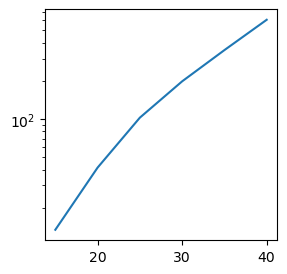

In [10]:
figure(figsize=(3,3))
semilogy(mode_numbers,run_time_s)
display(gcf())

In [11]:
run_time_s

6-element Vector{Float64}:
  13.417964333
  41.457169917
 102.622860541
 198.32767025
 349.576703041
 606.048916833

In [13]:
num_modes = 20;
properties = compute_fiber_properties(step_fiber, material, num_modes, polarization=:scalar, mode_basis=:LP, beta_order=3)
S_compressed = cp_compress(properties.S,error=1e-3);

In [17]:
  coefficients = zeros(ComplexF64, num_modes)

    coefficients[6:15] .= ComplexF64[
     0.042233154627023345 + 0.9991077822989120im,
    -0.9548483373690423   + 0.29709367651226704im,
     0.8131419320624027   - 0.5820654587946469im,
     0.18628501477914675  + 0.9824957472013469im,
     0.6319768780431223   + 0.7749872422297470im,
    -0.9492435495998746   + 0.31454202190332287im,
    -0.06792170771520316  - 0.9976906542716788im,
     0.3907153673065814   - 0.9205115435183218im,
     0.9992441657975882   - 0.03887283266604082im,
     0.6421650166589653   - 0.7665664298541848im,
    ]

    initial_field = gaussian_pulse(
        domain,
        num_modes;
        peak_power=751549.7920240875,    # total peak power across all modes, W
        fwhm=0.2499694427126389,          # intensity FWHM, ps
        time_offset=-30.002441147314094,  # ps
        coefficients=coefficients,
    )

    parameters = MMGNLSEParameters(domain;
        length=Δz,
        beta=properties.beta,
        S=S_compressed,
        n2=properties.n2,
        omega0=properties.omega0,
        raman=properties.raman)

    run_time_s = (@elapsed for _ in 1:1
        solution = solve_mmgnlse(initial_field, parameters, Δz);
        end) 

0.73818425

In [18]:
num_modes = 30;
properties = compute_fiber_properties(step_fiber, material, num_modes, polarization=:scalar, mode_basis=:LP, beta_order=3)
S_compressed = cp_compress(properties.S,error=1e-3);

In [25]:
S_compressed

MMGNLSECPDecomposition{Float64, ComplexF64}([2.8013294727600284e9, 1.821039241580735e9, 6.789365524793755e9, 2.3054588064585964e10, 1.6635094992017322e9, 3.792233064857748e10, 1.2389818186397805e9, 5.570089699959145e9, 1.923252541003442e10, 2.0579677144611428e9  …  2.5329121156091318e7, 2.894531562811892e7, 2.112058474486078e8, 1.4848695514969548e7, 7.628294417256153e7, 5.120724348815514e7, 4.850887209247331e7, 6.817751863527809e7, 1.0190515674345564e7, 2.778263499419789e6], (ComplexF64[-0.14424581734272013 - 0.14436747087079796im -0.23577917344222726 + 0.07065864791712695im … -0.15335233229530243 - 0.0075395628575659086im 0.03117729320559303 - 0.01842529564160472im; 0.20641787233204445 + 0.17460165738662833im 0.06548938008269294 - 0.06360490165955376im … -0.027933568723438527 - 0.01478234496836847im -0.035564532250520496 + 0.01275036894543985im; … ; -0.026530428984852368 + 0.07606550371672284im 0.24032857951610173 - 0.16357682757551617im … -0.21737300178473887 + 0.032395733064554566im